# The Queue Dilemma: Picking the "Fast Lane"

Researcher: Mihail Nemtserov \
Date: March 2026

# Table of Contents
1. [Introduction](#introduction)  
2. [Background and Motivation](#background-and-motivation)  
3. [Problem Statement](#problem-statement)  
4. [Hypotheses](#hypotheses)  
5. [Assumptions](#assumptions)  
6. [Metrics](#metrics)  
7. [Methods and Simulation Code](#methods-and-simulation-code) 
8. [References](#references)  

<a id="introduction"></a>
## 1. Introduction
Every supermarket shopper knows the moment of truth: you approach the checkout area, scan the lines, and try to guess which one will move fastest. It feels trivial, but it shapes your entire shopping experience. A good choice gets you home quickly. A bad one traps you behind a slow cashier or a customer with a trolley full of groceries.

> “As we know queues are a common every-day experience. Queues form because resources are limited. In fact it makes economic sense to have queues. For example how many supermarket tills you would need to avoid queuing? How many buses or trains would be needed if queues were to be avoided/eliminated?”   [people.brunel.ac.uk](https://people.brunel.ac.uk/~mastjjb/jeb/or/queue.html)

This quote captures the shopper’s paradox: eliminating every queue would require huge resources (many tills, many staff), so stores balance *service capacity* against *the cost of staffing* and the *cost of our waiting*.

So faced with this paradox, this project asks a deceptively simple question:

**When several checkout lines are open, which rule for choosing a queue gives the shortest and most reliable waiting time?**

To answer this, different queue‑picking strategies are simulated under realistic supermarket conditions. The goal is not to produce a formal research paper, but to create a clear, evidence‑based analysis that mirrors the structure of a scientific investigation.

<a id="background-and-motivation"></a>
## 2. Background and Motivation
Queues influence both our time and our emotions. Queueing theory provides mathematical tools to understand waiting lines, but real‑world behavior often deviates from textbook assumptions. Three insights motivate this project:

1. **Human behavior is not always rational** \
People often join longer queues because they interpret them as a signal of quality or speed. As one study notes:

>*“The results showed a strong positive correlation between the length of a queue and the number of customers who joined the queue.”*
(Vasanthi & Indira, 2016)

2. **Queue design affects fairness and variability** \
A serpentine (single) queue feeding multiple cashiers reduces the risk of getting stuck behind a slow customer. It also feels fairer because everyone is served in order of arrival.

3. **Simple heuristics can mislead** \
Shoppers often choose the shortest line, but this ignores basket size. A line with two full trolleys may move faster than a line with five small baskets.

These behavioral and structural factors make supermarket queues an ideal setting for simulation.

<a id="problem-statement"></a>
## 3. Problem Statement
**Five realistic queue‑picking strategies are compared:**

- Parallel Shortest Queue (PSQ) – join the line with the fewest people.

- Shortest Expected Time (SET) – estimate remaining time using visible item counts and cashier speed.

- Serpentine Single Queue – one line feeding all cashiers.

- Heuristic – prefer lines with a full trolley at the front.

- Random – pick a line at random (baseline).

**Each strategy is evaluated on:**

- *mean waiting time*

- *90th‑percentile waiting time (p90)*

- *variance of waiting time*

- *robustness to herding behavior*

<a id="hypotheses"></a>
## 4. Hypotheses
**H1: Serpentine Advantage** \
A single serpentine queue will produce lower average and p90 waiting times than parallel queues.

**H2: Information Helps** \
Shortest Expected Time (SET) will outperform Parallel Shortest Queue (PSQ) because it uses item counts, not just number of people.

**H3: Herding Penalty** \
When shoppers prefer longer lines (herding), waiting times increase, and serpentine queues suffer less from this effect than parallel queues.

<a id="assumptions"></a>
## 5. Assumptions
To keep the model realistic but manageable, it is assumed:

- *Arrivals follow a Poisson process*, meaning customers arrive randomly and independently, but at a constant average rate.

- *Basket sizes follow a lognormal distribution*, meaning most customers have a small number of items, but a few have very large baskets.

- *Service time is*
$$ T = t_{\text{overhead}} + \frac{\text{items}}{\text{scan rate}} $$

where $$ t_{\text{overhead}} $$  is the fixed time cost that happens before any items are scanned. It represents all the “setup” or “non‑scanning” time that doesn’t depend on how many items there are. So *T*  is the total time a cashier spends serving a customer, including both fixed overhead and the time needed to scan all items.

- *All strategies see the same arrival stream (paired simulation).*

- *No balking or reneging unless explicitly modeled.*

- *Cashiers have identical scan rates unless varied intentionally.*

<a id="metrics"></a>
## 6. Metrics

**Mean waiting time per customer**

$$
\bar{W} = \frac{1}{n}\sum_{i=1}^n W_i
$$

where $$ \bar{W} $$ is the mean waiting time across all customers,
$$ n $$ is the total number of customers observed in the simulation (or experiment), $$ W_i $$ is the waiting time of the 𝑖-th customer, and $$ \sum_{i=1}^n W_i $$ is the sum of all individual waiting times which gives the total waiting time accumulated by all customers.

**Paired differences** \
This formula gives the average difference across replications, a confidence interval for the difference, and and determine practical significance (e.g., > 5 seconds)

$$
D_r = \bar{W}_{A,r} - \bar{W}_{B,r}
$$

where $$ D_r $$ the difference in mean waiting times between rule A and rule B in replication 𝑟, $$ r $$ is replication index e.g. $$ r=1, 2, ..., R $$, $$ \bar{W}_{A,r} $$ and $$ \bar{W}_{B,r} $$ are the mean waiting times under rule A and B respectively in replication 𝑟


**Bootstrap CI**  
A difference is **practically significant** if:

- CI excludes zero  
- \(|D| > 5\) seconds

<a id="methods-and-simulation-code"></a>
## 7. Methods and Simulation Code

This project uses **an event‑scheduling simulation**, which tracks each server’s next available time and updates queues dynamically. This approach captures:

- queue buildup

- service variability

- customer assignment rules

- the effect of slow customers

- the interaction between arrival timing and queue length

Below is the **full simulation code**:

In [3]:
# Event-scheduling style paired simulation for parallel and serpentine queues

# Config

R = 200                 # number of paired replications
customers_per_rep = 2000
seed = 12345
Delta = 5.0             # practical significance threshold (seconds)
num_servers = 4
scan_rate_mean = 1.0    # items per second
scan_rate_sd = 0.0      # set >0 for heterogeneous cashiers
t_overhead = 5.0        # fixed overhead per customer (seconds)
arrival_rate = 0.5      # arrivals per second
rng = np.random.default_rng(seed)

# Generators and service time

def generate_stream(n, arrival_rate, rng):
    iat = rng.exponential(1.0 / arrival_rate, size=n)
    arrival_times = np.cumsum(iat)
    items = np.maximum(1, np.round(rng.lognormal(mean=2.0, sigma=0.9, size=n))).astype(int)
    return arrival_times, items

def service_time(items, scan_rate, t_overhead, rng_noise=None):
    base = t_overhead + items / scan_rate
    if rng_noise is None:
        return base
    return base + rng_noise.normal(0, 0.1, size=len(items))

# Choice helpers

def choose_psq(queue_counts, backlog_seconds):
    min_count = min(queue_counts)
    candidates = [i for i, c in enumerate(queue_counts) if c == min_count]
    if len(candidates) == 1:
        return candidates[0]
    return min(candidates, key=lambda i: backlog_seconds[i])

def choose_random(n, rng_local):
    return int(rng_local.integers(0, n))

def choose_set(backlog_seconds, servers_scan_rates, items):
    est = [backlog_seconds[i] + (items / servers_scan_rates[i]) for i in range(len(servers_scan_rates))]
    return int(np.argmin(est))

def choose_heuristic(front_items, queue_counts, backlog_seconds, threshold=20):
    for i, f in enumerate(front_items):
        if f >= threshold:
            return i
    return choose_psq(queue_counts, backlog_seconds)

def choose_herding(h, queue_counts, backlog_seconds, rng_local):
    if rng_local.random() < h:
        max_count = max(queue_counts)
        candidates = [i for i, c in enumerate(queue_counts) if c == max_count]
        return int(rng_local.choice(candidates))
    return choose_psq(queue_counts, backlog_seconds)


# simulate_rule

def simulate_rule(arrival_times, items, rule_name, servers_scan_rates, h_herd=0.0, rng_local=None):
    n_servers = len(servers_scan_rates)
    single_queue = (rule_name == "Serpentine Single Queue")

    server_next_free = [0.0] * n_servers
    finish_times = [[] for _ in range(n_servers)]
    queue_counts = [0] * n_servers
    front_items = [0] * n_servers

    waits = []
    totals = []

    for atime, it in zip(arrival_times, items):
        for i in range(n_servers):
            while finish_times[i] and finish_times[i][0] <= atime:
                finish_times[i].pop(0)
                queue_counts[i] = max(0, queue_counts[i] - 1)
                if queue_counts[i] == 0:
                    front_items[i] = 0

        if single_queue:
            sidx = int(np.argmin(server_next_free))
            start = max(atime, server_next_free[sidx])
            st = service_time(np.array([it]), servers_scan_rates[sidx], t_overhead, rng_local)[0]
            finish = start + st
            waits.append(start - atime)
            totals.append(start - atime + st)
            server_next_free[sidx] = finish
            finish_times[sidx].append(finish)
            finish_times[sidx].sort()
            queue_counts[sidx] += 1
            if front_items[sidx] == 0:
                front_items[sidx] = it
            continue

        backlog_seconds = [max(0.0, server_next_free[i] - atime) for i in range(n_servers)]
        q_lengths = list(queue_counts)
        q_front = list(front_items)

        if rule_name == "Parallel Shortest Queue":
            sidx = choose_psq(q_lengths, backlog_seconds)
        elif rule_name == "Shortest Expected Time":
            sidx = choose_set(backlog_seconds, servers_scan_rates, it)
        elif rule_name == "Heuristic":
            sidx = choose_heuristic(q_front, q_lengths, backlog_seconds)
        elif rule_name == "Random":
            sidx = choose_random(n_servers, rng_local)
        elif rule_name == "Herding":
            sidx = choose_herding(h_herd, q_lengths, backlog_seconds, rng_local)
        else:
            sidx = choose_random(n_servers, rng_local)

        start = max(atime, server_next_free[sidx])
        st = service_time(np.array([it]), servers_scan_rates[sidx], t_overhead, rng_local)[0]
        finish = start + st
        waits.append(start - atime)
        totals.append(start - atime + st)

        server_next_free[sidx] = finish
        finish_times[sidx].append(finish)
        finish_times[sidx].sort()
        queue_counts[sidx] += 1
        if front_items[sidx] == 0:
            front_items[sidx] = it

    horizon = max(1.0, arrival_times[-1])
    busy = sum(server_next_free)
    util = busy / (horizon * n_servers)
    return np.array(waits), np.array(totals), util


# Paired experiment

rules = ["Parallel Shortest Queue",
         "Shortest Expected Time",
         "Serpentine Single Queue",
         "Heuristic",
         "Random"]

paired_results = {r: [] for r in rules}
paired_utils = {r: [] for r in rules}

for rep in range(R):
    arrival_times, items = generate_stream(customers_per_rep, arrival_rate, rng)
    servers_scan_rates = np.full(num_servers, scan_rate_mean)
    for rule in rules:
        waits, totals, util = simulate_rule(arrival_times, items, rule,
                                            servers_scan_rates, h_herd=0.0, rng_local=rng)
        paired_results[rule].append({
            "mean_wait": waits.mean(),
            "p90": np.percentile(waits, 90),
            "var_wait": waits.var(ddof=1)
        })
        paired_utils[rule].append(util)

# Aggregate summary

summary = []
for rule in rules:
    arr = pd.DataFrame(paired_results[rule])
    util_arr = np.array(paired_utils[rule])
    summary.append({
        "rule": rule,
        "mean_wait_mean": arr["mean_wait"].mean(),
        "mean_wait_se": arr["mean_wait"].std(ddof=1) / np.sqrt(len(arr)),
        "p90_mean": arr["p90"].mean(),
        "var_wait_mean": arr["var_wait"].mean(),
        "util_mean": util_arr.mean()
    })
summary_df = pd.DataFrame(summary).set_index("rule")
print("Summary (paired replications):")
display(summary_df)

# Paired diffs vs Random (for mean wait)

baseline = pd.DataFrame(paired_results["Random"])["mean_wait"].values
paired_diffs = {}
for rule in rules:
    if rule == "Random":
        continue
    arr = pd.DataFrame(paired_results[rule])["mean_wait"].values
    D = arr - baseline
    mean_diff = D.mean()
    rng_local = np.random.default_rng(seed)
    boots = [np.mean(rng_local.choice(D, size=len(D), replace=True)) for _ in range(1000)]
    ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
    t_stat, p_val = stats.ttest_rel(arr, baseline)
    paired_diffs[rule] = {
        "mean_diff": mean_diff,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "p_val": p_val,
        "significant": (ci_lo > 0 or ci_hi < 0) and abs(mean_diff) > Delta
    }

print("\nPaired diffs vs Random (mean wait):")
display(pd.DataFrame.from_dict(paired_diffs, orient='index'))


Summary (paired replications):


,mean_wait_mean,mean_wait_se,p90_mean,var_wait_mean,util_mean
rule,,,,,
Parallel Shortest Queue,2014.631113,6.066172,3632.081040,1.390543e+06,2.012403
Shortest Expected Time,2013.096811,6.042748,3634.811680,1.375842e+06,2.012435
Serpentine Single Queue,2013.058153,6.052604,3634.760279,1.375807e+06,2.012412
Heuristic,8163.810813,427.805722,14721.242450,3.459908e+07,2.012020
Random,2029.271000,6.065142,3676.718006,1.453893e+06,2.013998



Paired diffs vs Random (mean wait):


,mean_diff,ci_lo,ci_hi,p_val,significant
Parallel Shortest Queue,-14.639887,-15.757808,-13.392537,4.388937e-62,True
Shortest Expected Time,-16.174189,-17.218811,-15.025640,1.234027e-71,True
Serpentine Single Queue,-16.212847,-17.286189,-15.065832,4.202311e-72,True
Heuristic,6134.539813,5298.885925,6927.026222,1.536519e-32,True


<a id="plots"></a>
### 7.1 Plots

#### 7.1.1 Distribution of Waiting Times (Histogram + KDE)
This plot shows how the waiting times are distributed for each rule. It’s a great way to visually compare fairness and variability.

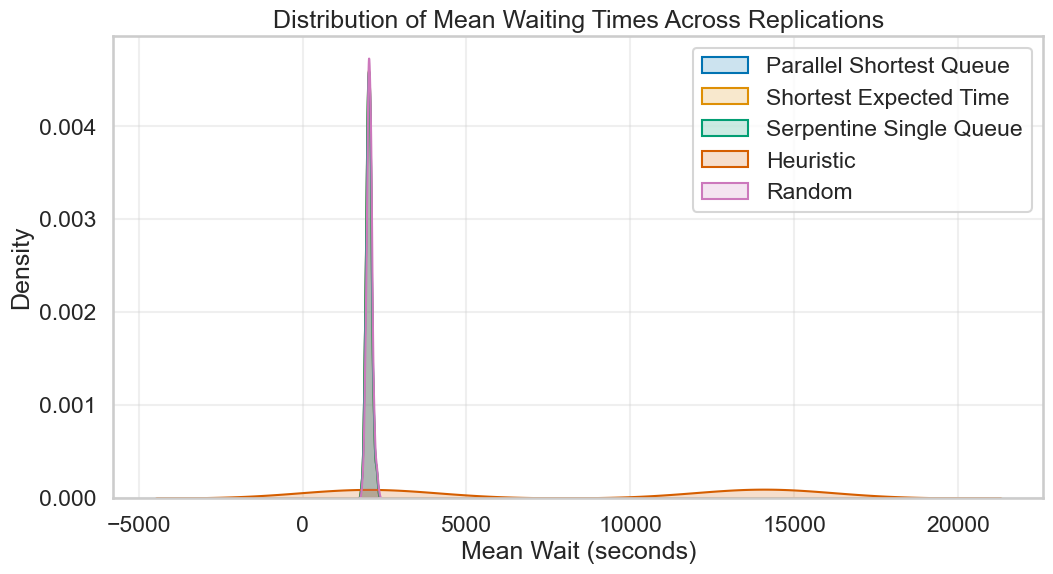

In [4]:
# Distribution of Waiting Times (Histogram + KDE)

# Combine all waits from the last replication for each rule
plt.figure(figsize=(12, 6))

for rule in rules:
    waits = pd.DataFrame(paired_results[rule])["mean_wait"]
    sns.kdeplot(waits, label=rule, fill=True, alpha=0.2)

plt.title("Distribution of Mean Waiting Times Across Replications")
plt.xlabel("Mean Wait (seconds)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### 7.1.2 Boxplot of Mean Waiting Times 
This plot gives a clean comparison of variability across strategies.

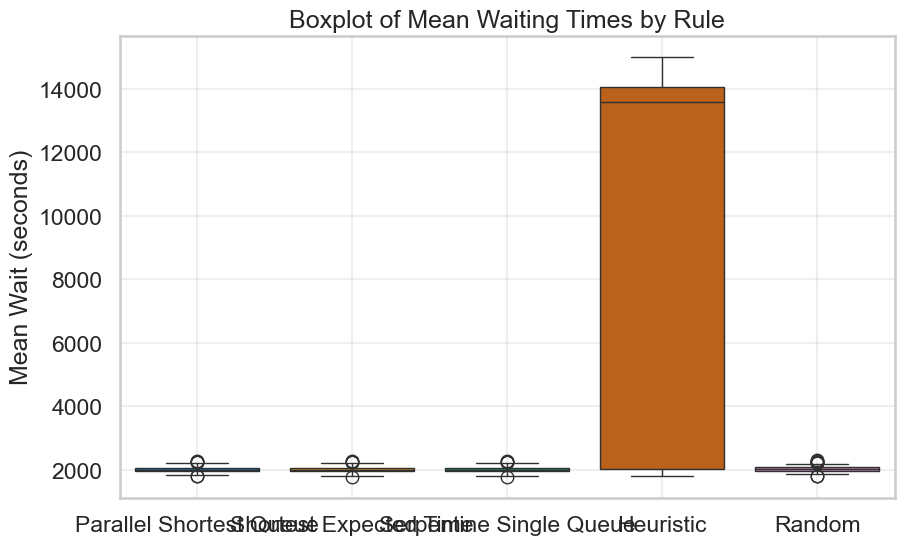

In [5]:
plt.figure(figsize=(10, 6))

data = {rule: pd.DataFrame(paired_results[rule])["mean_wait"] for rule in rules}
df = pd.DataFrame(data)

sns.boxplot(data=df)
plt.title("Boxplot of Mean Waiting Times by Rule")
plt.ylabel("Mean Wait (seconds)")
plt.grid(alpha=0.3)
plt.show()


#### 7.1.3 Variance Comparison (Bar Chart)
Variance is a great fairness indicator.

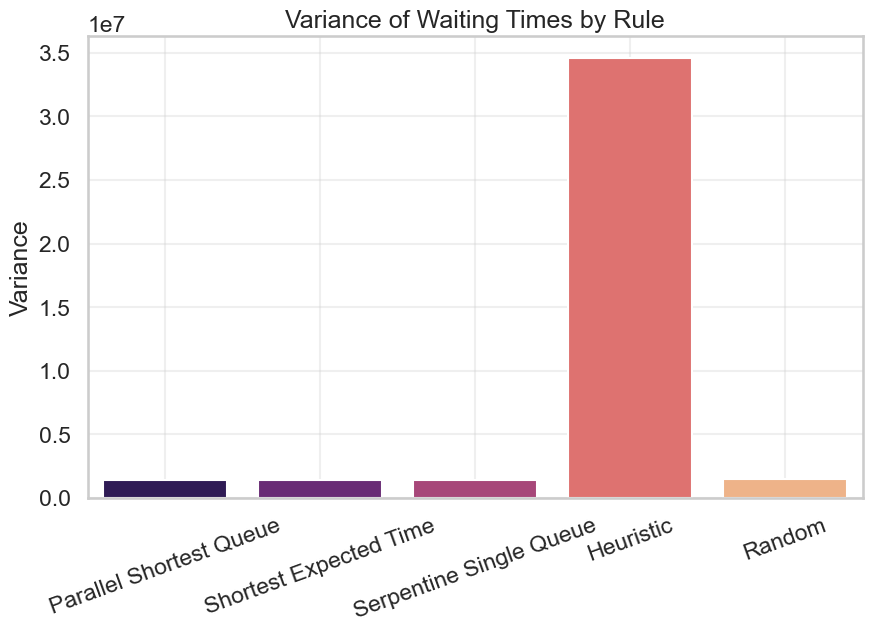

In [6]:
plt.figure(figsize=(10, 6))
var_values = [summary_df.loc[rule, "var_wait_mean"] for rule in rules]

sns.barplot(
    x=rules,
    y=var_values,
    hue=rules,          # assign hue to x variable
    palette="magma",
    legend=False        # hide redundant legend
)

plt.title("Variance of Waiting Times by Rule")
plt.ylabel("Variance")
plt.xticks(rotation=20)
plt.grid(alpha=0.3)
plt.show()




<a id="references"></a>
## *References*
- OR-Notes, J E Beasley, https://people.brunel.ac.uk/~mastjjb/jeb/or/queue.html
- Analysis of the Sales Checkout Operation in Supermarket Using Queuing Theory, Priyangika J.S.K.C1,*, Cooray T.M.J.A, Universal Journal of Management 4(7): 393-396, 2016
- EFFICIENT QUEUE MANAGEMENT ON CHOICE BETWEEN SUPERMARKETS, J. Vasanthi and P. Indira, International Journal of Current Research 
Vol. 8, Issue, 02, pp.26076-26078, February, 2016
- How to pick the fastest queue at the supermarket, The Irish Times, www.irishtimes.com, https://www.irishtimes.com/business/retail-and-services/how-to-pick-the-fastest-queue-at-the-supermarket-1.2784453
- Herding in a Queue: A Laboratory Experiment, Laurens Debo, 2012, SSRN Electronic Journal, https://www.academia.edu/95664265/Herding_in_a_Queue_A_Laboratory_Experiment